In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from typing import TypedDict, Literal

In [31]:
# creating schemas

class SentimentSchema(BaseModel):
    sentiment:Literal['positive', 'negative'] = Field(description="sentiment of the review")


class DiagnosisSchema(BaseModel):
    issue_type:Literal['bug', 'performance', 'UX', 'support', 'other'] = Field(description="type of issue that user is facing")

    tone:Literal['angry', 'frustrated', 'calm', 'disappointed'] = Field(description="tone in which user is expressing his message")

    urgency:Literal['low', 'medium', 'high'] = Field(description="How urgent or critical the issue is")

In [32]:
# Creating model instances

model = ChatOllama(model="qwen2.5:1.5b")

sentiment_model = model.with_structured_output(SentimentSchema)
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [33]:
# Creating state for the graph

class ReviewState(TypedDict):
    review:str
    sentiment:Literal['positive', 'negative']
    diagnosis:dict
    response:str

In [34]:
# Node for sentiment analysis

def sentiment_analysis(state : ReviewState):
    review = state['review']

    prompt = f'Find out the sentiment of the following review\n{review}'

    result = sentiment_model.invoke(prompt).sentiment

    return {'sentiment':result}

In [35]:
# Node for diagnosis of review

def diagnose_review(state : ReviewState):
    review = state['review']

    prompt = f'Diagnose the following review and find out issue type, tone of the customer and urgency of the issue\n{review}'

    result = diagnosis_model.invoke(prompt)

    return {'diagnosis':result.model_dump()}

In [36]:
# Node for generating positive response

def positive_response(state : ReviewState):
    review = state['review']

    prompt = f'Generate a positive, thankfull and humble response for the following review\n{review}'

    result = model.invoke(prompt).content

    return {'respone':result}

In [ ]:
# Node for generating negative response

def negative_response(state : ReviewState):
    review = state['review']
    diagnosis = state['diagnosis']

    prompt = f'Generate a short, apologetic, empathetic and helpful response for the following review where customer is facing {diagnosis['issue_type']} issue and he is {diagnosis['tone']} and the urgency of issue is {diagnosis['urgency']}\n{review}'

    result = model.invoke(prompt).content

    return {'response':result}

In [38]:
# Creating conditional function

def eval_condition(state : ReviewState) -> Literal['positive_response', 'diagnose_review']:
    sentiment = state['sentiment']

    if(sentiment == 'positive'):
        return 'positive_response'
    else:
        return 'diagnose_review'

In [39]:
# Creating graph

graph = StateGraph(ReviewState)

graph.add_node('sentiment_analysis', sentiment_analysis)
graph.add_node('diagnose_review', diagnose_review)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'sentiment_analysis')
graph.add_conditional_edges('sentiment_analysis', eval_condition)
graph.add_edge('positive_response', END)
graph.add_edge('diagnose_review', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

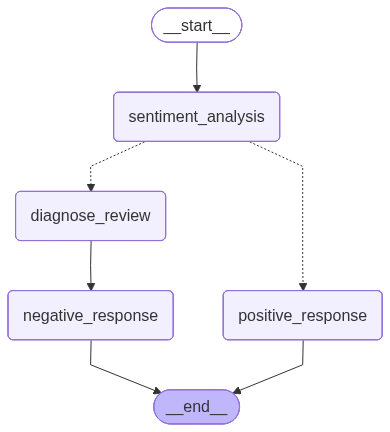

In [40]:
workflow

In [41]:
review = "The user interface of the website is very cluttered and a normal, non tech person cannot easily learn this platform. It is a request from development team to make the design minimal and user friendly."

initial_state = {
    'review':review
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'review': 'The user interface of the website is very cluttered and a normal, non tech person cannot easily learn this platform. It is a request from development team to make the design minimal and user friendly.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'UX', 'tone': 'disappointed', 'urgency': 'high'}}
